# 🏅 Notebook 2: Elo Rating System

**Goal:** Build a strength rating for every international football team from 150 years of match data.

In this notebook you will:
1. **Understand** what Elo is and why it works
2. **Build it by hand** — one match at a time — so you really get it
3. **Scale it up** across all 49,000+ matches using our `src/elo.py` module
4. **Visualise** the final rankings and how team ratings evolved over time
5. **Save** the ratings to use in Notebook 3 (Poisson model)

---

## 🧠 What is Elo?

Elo was invented by physicist **Arpad Elo** in 1960 for chess. The idea is simple:

> Every player/team has a **rating number**. After each match, the winner takes points from the loser. How many points? Depends on how *surprising* the result was.

- Beat a team rated **much higher** than you → gain **lots** of points (big upset)
- Beat a team rated **much lower** than you → gain **few** points (expected result)
- Lose to a stronger team → lose **few** points
- Lose to a weaker team → lose **lots** of points

**Used in:** Chess, FIFA world rankings, League of Legends, Table Tennis, Tennis, and more.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from src.utils import load_results
from src.elo import (
    expected_result,
    update_ratings,
    build_elo_ratings,
    build_elo_history,
    ratings_to_dataframe,
    DEFAULT_RATING, HOME_ADVANTAGE, K_BASE
)

plt.rcParams['figure.figsize']    = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size']         = 11

print('✓ Ready')
print(f'  Default starting rating : {DEFAULT_RATING}')
print(f'  Home advantage bonus    : {HOME_ADVANTAGE} Elo points')
print(f'  Base K-factor           : {K_BASE}')

✓ Ready
  Default starting rating : 1500
  Home advantage bonus    : 100 Elo points
  Base K-factor           : 40


## Part 1 — The Elo Formula (Built by Hand)

There are only **two equations** to learn.

### Equation 1: Expected Result

$$E_{home} = \frac{1}{1 + 10^{\frac{R_{away} - R_{home} - \text{HomeAdv}}{400}}}$$

This gives a number between 0 and 1 — the home team's **expected score**:
- `E = 1.0` → home team is *guaranteed* to win  
- `E = 0.5` → 50/50 match  
- `E = 0.0` → away team is *guaranteed* to win

### Equation 2: Rating Update

$$\Delta R = K \times (\text{Actual} - E_{home})$$

Where `Actual` = 1 (home win), 0.5 (draw), 0 (away win)

The home team gains `ΔR` points; the away team loses `ΔR` points. **It's zero-sum.**

In [2]:
# ── Step-by-step manual example ──────────────────────────────────────────────
# Let's simulate: Brazil (home) vs Germany (away)
# Suppose Brazil's rating = 1800, Germany's rating = 1750

R_brazil  = 1800
R_germany = 1750
K         = 40       # K-factor (World Cup match)
home_adv  = 100      # home advantage bonus

# ── STEP 1: Calculate expected result for Brazil (home) ───────────────────────
E_brazil = 1 / (1 + 10 ** ((R_germany - R_brazil - home_adv) / 400))
print('─' * 55)
print('EXAMPLE: Brazil (home, 1800) vs Germany (away, 1750)')
print('─' * 55)
print(f'Expected result for Brazil  : {E_brazil:.4f}  ({E_brazil*100:.1f}% chance to win)')
print(f'Expected result for Germany : {1-E_brazil:.4f}  ({(1-E_brazil)*100:.1f}% chance to win)')
print()

# ── STEP 2: Actual result — Brazil wins 2-1 ───────────────────────────────────
actual = 1.0  # home win

delta = K * (actual - E_brazil)

print(f'Actual result               : Brazil wins (actual = 1.0)')
print(f'Rating change (ΔR)          : {delta:+.2f} points')
print()
print(f'Brazil new rating           : {R_brazil:.0f} → {R_brazil + delta:.1f}  (+{delta:.1f})')
print(f'Germany new rating          : {R_germany:.0f} → {R_germany - delta:.1f}  ({-delta:+.1f})')
print()
print('🔍 Brazil only gains ~{:.0f} pts because they were already favoured.'.format(delta))

───────────────────────────────────────────────────────
EXAMPLE: Brazil (home, 1800) vs Germany (away, 1750)
───────────────────────────────────────────────────────
Expected result for Brazil  : 0.7034  (70.3% chance to win)
Expected result for Germany : 0.2966  (29.7% chance to win)

Actual result               : Brazil wins (actual = 1.0)
Rating change (ΔR)          : +11.86 points

Brazil new rating           : 1800 → 1811.9  (+11.9)
Germany new rating          : 1750 → 1738.1  (-11.9)

🔍 Brazil only gains ~12 pts because they were already favoured.


In [3]:
# ── What if Germany pulls the upset? ─────────────────────────────────────────
actual_upset = 0.0  # away win

delta_upset = K * (actual_upset - E_brazil)

print('─' * 55)
print('SAME MATCH — but Germany wins (upset!)')
print('─' * 55)
print(f'Rating change (ΔR)          : {delta_upset:+.2f} points')
print()
print(f'Brazil new rating           : {R_brazil:.0f} → {R_brazil + delta_upset:.1f}  ({delta_upset:+.1f})')
print(f'Germany new rating          : {R_germany:.0f} → {R_germany - delta_upset:.1f}  (+{-delta_upset:.1f})')
print()
print('🔍 Germany gains {:.0f} pts — much more because it was an upset!'.format(-delta_upset))

───────────────────────────────────────────────────────
SAME MATCH — but Germany wins (upset!)
───────────────────────────────────────────────────────
Rating change (ΔR)          : -28.14 points

Brazil new rating           : 1800 → 1771.9  (-28.1)
Germany new rating          : 1750 → 1778.1  (+28.1)

🔍 Germany gains 28 pts — much more because it was an upset!


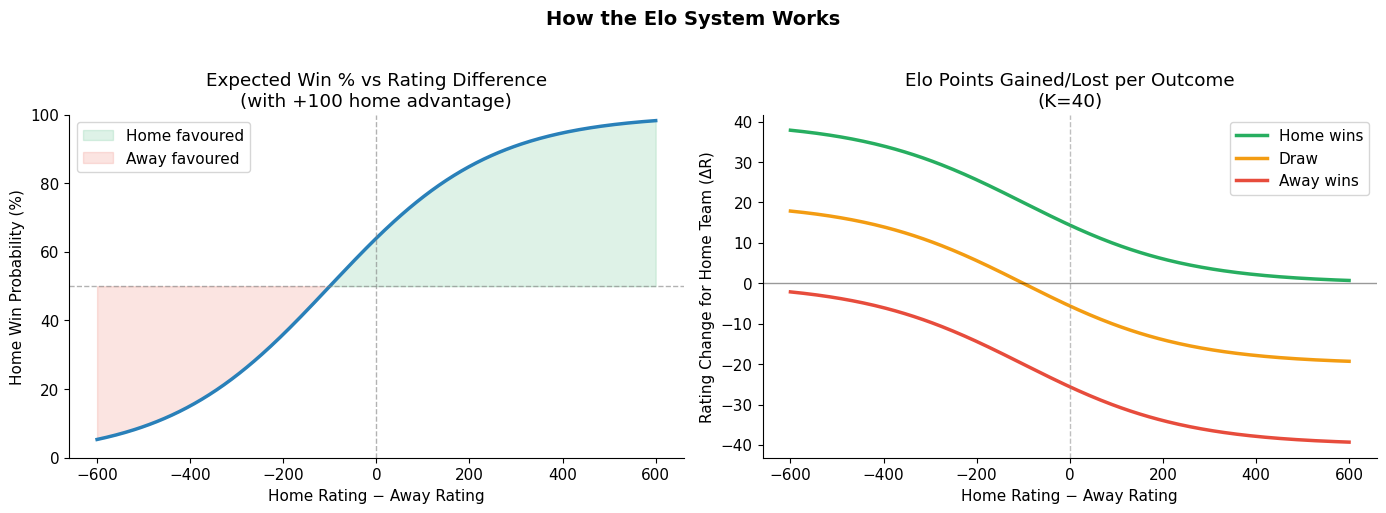

Key takeaway:
  • Win vs weaker team  → small gain  (expected)
  • Win vs stronger team → large gain (surprise!)
  • Lose to weaker team  → large loss (embarrassing!)


In [4]:
# ── Visualise: Elo rating change vs rating difference ─────────────────────────
# How does the rating change vary with the skill gap?

rating_diffs = np.linspace(-600, 600, 300)  # home rating minus away rating

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Expected result probability vs rating difference
ax = axes[0]
E_vals = 1 / (1 + 10 ** ((-rating_diffs - home_adv) / 400))
ax.plot(rating_diffs, E_vals * 100, color='#2980b9', linewidth=2.5)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(0,  color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.fill_between(rating_diffs, E_vals * 100, 50, where=E_vals > 0.5,
                alpha=0.15, color='#27ae60', label='Home favoured')
ax.fill_between(rating_diffs, E_vals * 100, 50, where=E_vals < 0.5,
                alpha=0.15, color='#e74c3c', label='Away favoured')
ax.set_xlabel('Home Rating − Away Rating')
ax.set_ylabel('Home Win Probability (%)')
ax.set_title('Expected Win % vs Rating Difference\n(with +100 home advantage)')
ax.legend()
ax.set_ylim(0, 100)

# Plot 2: Rating points gained/lost for each outcome
ax = axes[1]
delta_win  = K * (1.0 - E_vals)
delta_draw = K * (0.5 - E_vals)
delta_loss = K * (0.0 - E_vals)

ax.plot(rating_diffs, delta_win,  color='#27ae60', linewidth=2.5, label='Home wins')
ax.plot(rating_diffs, delta_draw, color='#f39c12', linewidth=2.5, label='Draw')
ax.plot(rating_diffs, delta_loss, color='#e74c3c', linewidth=2.5, label='Away wins')
ax.axhline(0, color='black', linewidth=1, alpha=0.4)
ax.axvline(0, color='gray',  linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Home Rating − Away Rating')
ax.set_ylabel('Rating Change for Home Team (ΔR)')
ax.set_title(f'Elo Points Gained/Lost per Outcome\n(K={K})')
ax.legend()

plt.suptitle('How the Elo System Works', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/02_elo_formula.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key takeaway:')
print('  • Win vs weaker team  → small gain  (expected)')
print('  • Win vs stronger team → large gain (surprise!)')
print('  • Lose to weaker team  → large loss (embarrassing!)')

## Part 2 — The K-Factor & Tournament Weights

The **K-factor** controls how *sensitive* the rating is. High K = ratings move fast. Low K = ratings are stable.

We use **different K-factors by tournament type** because:
- A World Cup final matters more than a friendly
- We don't want a friendly win over a weak team to inflate a rating

In [5]:
from src.utils import tournament_weight

# Show tournament weights
sample_tournaments = [
    'FIFA World Cup',
    'Copa América',
    'UEFA Euro',
    'Africa Cup of Nations',
    'FIFA World Cup qualification',
    'UEFA Euro qualification',
    'Friendly',
    'CONCACAF Gold Cup',
]

print(f'Base K-factor = {K_BASE}')
print()
print(f'{"Tournament":<35} {"Weight":<8} {"Effective K"}')
print('─' * 58)
for t in sample_tournaments:
    w  = tournament_weight(t)
    eff_k = K_BASE * w
    bar = '█' * int(eff_k / 2)
    print(f'{t:<35} {w:<8.2f} {eff_k:<6.1f}  {bar}')

Base K-factor = 40

Tournament                          Weight   Effective K
──────────────────────────────────────────────────────────
FIFA World Cup                      1.00     40.0    ████████████████████
Copa América                        0.50     20.0    ██████████
UEFA Euro                           0.85     34.0    █████████████████
Africa Cup of Nations               0.50     20.0    ██████████
FIFA World Cup qualification        0.65     26.0    █████████████
UEFA Euro qualification             0.85     34.0    █████████████████
Friendly                            0.30     12.0    ██████
CONCACAF Gold Cup                   0.50     20.0    ██████████


## Part 3 — Build Ratings Across ALL Matches

Now we replay **every match in history** in chronological order. Each match updates two teams' ratings. After 49,000+ matches, each team's final number reflects their true strength.

In [6]:
# Load data — we use 1960 onwards for Elo
# (Pre-WWII data is too sparse and teams have changed a lot)
df = load_results(min_year=1960)

print(f'Matches loaded: {len(df):,}')
print(f'Date range:     {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Unique teams:   {len(set(df["home_team"]) | set(df["away_team"]))}')

Matches loaded: 44,530
Date range:     1960-01-01 → 2026-07-18
Unique teams:   333


In [7]:
# ── Build the ratings ─────────────────────────────────────────────────────────
# This iterates through every match and updates ratings.
# It takes ~10-20 seconds depending on your machine.

print('Building Elo ratings across all matches...')

ratings_dict = build_elo_ratings(
    df,
    default_rating = DEFAULT_RATING,   # 1500 for all new teams
    home_advantage = HOME_ADVANTAGE,   # +100 for home teams
    k_base         = K_BASE            # 40 base sensitivity
)

# Convert to a sorted DataFrame
ratings_df = ratings_to_dataframe(ratings_dict)

print(f'Done! Rated {len(ratings_df)} teams.')
print()
print(f'Highest rated team: {ratings_df.iloc[0]["team"]}  ({ratings_df.iloc[0]["elo_rating"]:.0f})')
print(f'Lowest rated team:  {ratings_df.iloc[-1]["team"]} ({ratings_df.iloc[-1]["elo_rating"]:.0f})')
print(f'Average rating:     {ratings_df["elo_rating"].mean():.0f}  (should be near 1500)')

Building Elo ratings across all matches...
Done! Rated 333 teams.

Highest rated team: Spain  (2059)
Lowest rated team:  San Marino (964)
Average rating:     1500  (should be near 1500)


In [8]:
# Top 30 teams
print('TOP 30 INTERNATIONAL TEAMS — Elo Rankings')
print('=' * 45)
top30 = ratings_df.head(30).copy()
for _, row in top30.iterrows():
    bar    = '█' * int((row['elo_rating'] - 1400) / 15)
    marker = ' ← No.1' if row['rank'] == 1 else ''
    print(f"{row['rank']:>3}. {row['team']:<25} {row['elo_rating']:>7.1f}  {bar}{marker}")

TOP 30 INTERNATIONAL TEAMS — Elo Rankings
  1. Spain                      2058.8  ███████████████████████████████████████████ ← No.1
  2. Argentina                  2049.4  ███████████████████████████████████████████
  3. France                     1972.2  ██████████████████████████████████████
  4. England                    1968.6  █████████████████████████████████████
  5. Brazil                     1913.5  ██████████████████████████████████
  6. Colombia                   1899.5  █████████████████████████████████
  7. Portugal                   1895.8  █████████████████████████████████
  8. Netherlands                1883.5  ████████████████████████████████
  9. Belgium                    1868.1  ███████████████████████████████
 10. Morocco                    1866.4  ███████████████████████████████
 11. Germany                    1852.3  ██████████████████████████████
 12. Mexico                     1848.1  █████████████████████████████
 13. Japan                      1836.5  █████

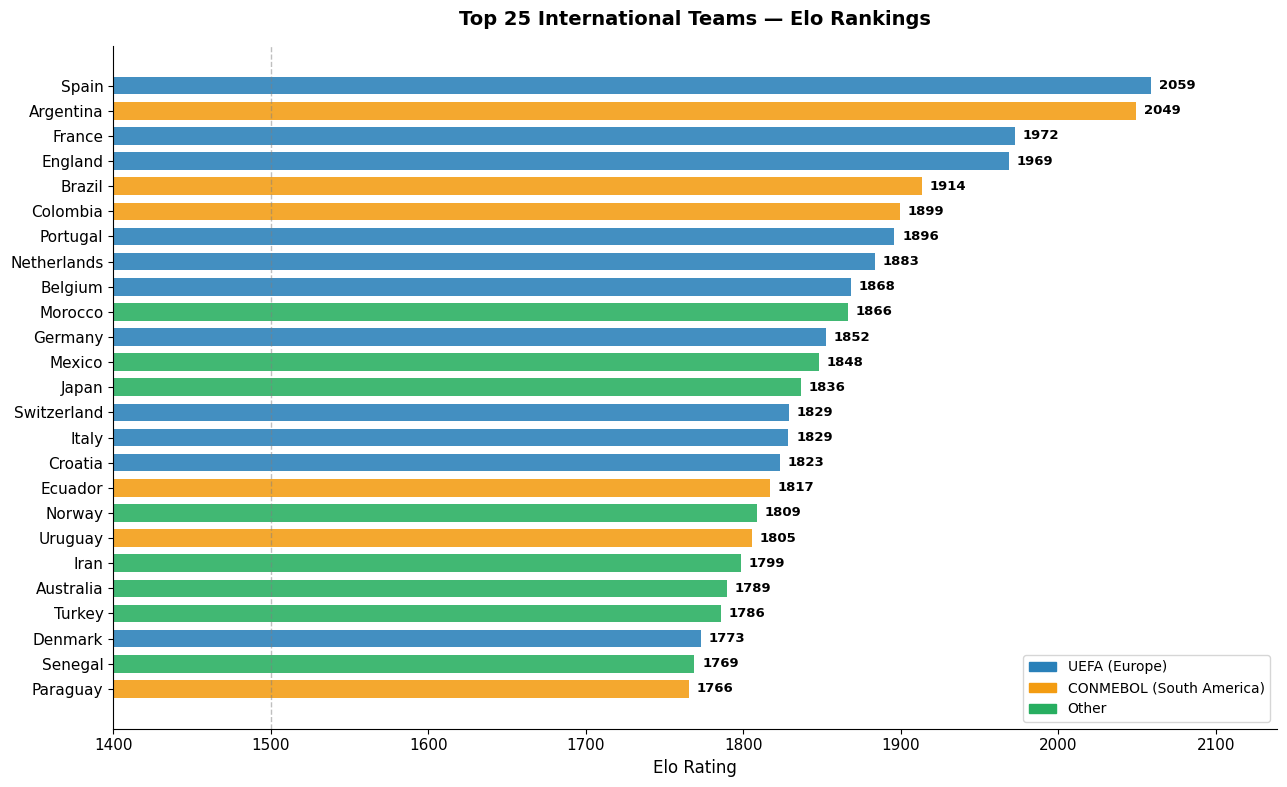

In [9]:
# ── Visualise top 25 teams ────────────────────────────────────────────────────
top25 = ratings_df.head(25)

# Colour code by confederation (rough)
south_america = ['Brazil','Argentina','Uruguay','Colombia','Chile','Ecuador','Paraguay','Peru']
europe        = ['Spain','France','Germany','Portugal','Netherlands','Belgium','England',
                 'Italy','Croatia','Denmark','Switzerland','Austria','Poland','Serbia']

colors = []
for team in top25['team']:
    if team in south_america:
        colors.append('#f39c12')   # orange = CONMEBOL
    elif team in europe:
        colors.append('#2980b9')   # blue = UEFA
    else:
        colors.append('#27ae60')   # green = other

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(top25['team'][::-1], top25['elo_rating'][::-1],
               color=colors[::-1], alpha=0.88, height=0.7)

# Labels
for bar, val in zip(bars, top25['elo_rating'][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=9.5, fontweight='bold')

# Legend
legend_patches = [
    mpatches.Patch(color='#2980b9', label='UEFA (Europe)'),
    mpatches.Patch(color='#f39c12', label='CONMEBOL (South America)'),
    mpatches.Patch(color='#27ae60', label='Other'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=10)

ax.set_xlim(1400, top25['elo_rating'].max() + 80)
ax.set_xlabel('Elo Rating', fontsize=12)
ax.set_title('Top 25 International Teams — Elo Rankings', fontsize=14, pad=15, fontweight='bold')
ax.axvline(1500, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Average (1500)')

plt.tight_layout()
plt.savefig('../outputs/02_top25_rankings.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 4 — Rating Distribution

What does the full spread of ratings look like across all 200+ nations?

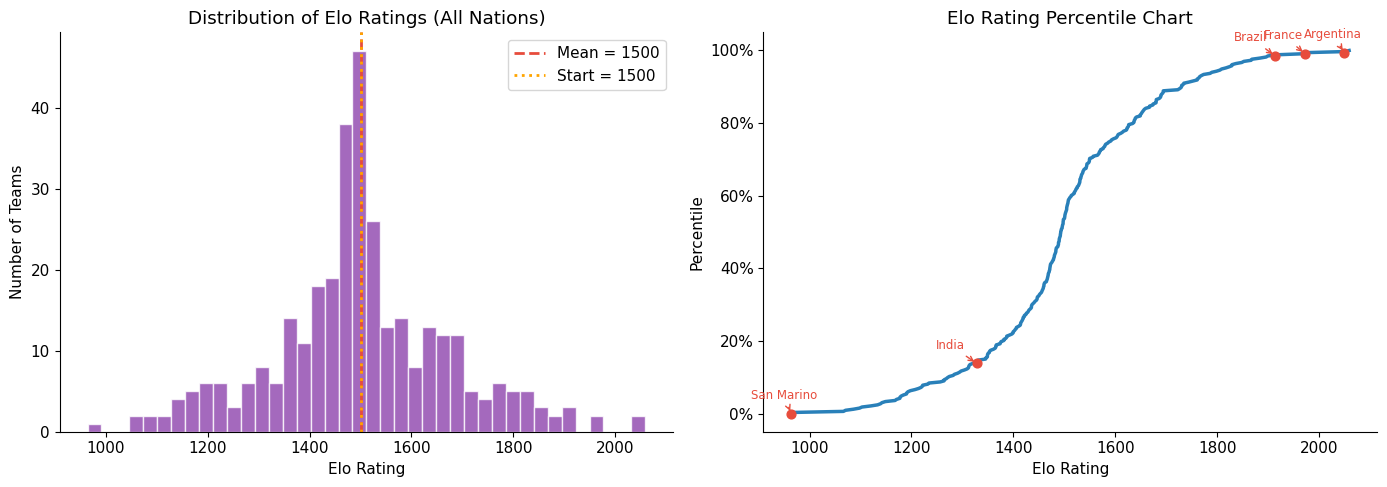

Rating statistics:
  Min  : 964  (San Marino)
  Max  : 2059  (Spain)
  Mean : 1500
  Std  : 175


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(ratings_df['elo_rating'], bins=40, color='#8e44ad', alpha=0.8, edgecolor='white')
ax.axvline(ratings_df['elo_rating'].mean(), color='#e74c3c', linewidth=2,
           linestyle='--', label=f'Mean = {ratings_df["elo_rating"].mean():.0f}')
ax.axvline(1500, color='orange', linewidth=2,
           linestyle=':', label='Start = 1500')
ax.set_xlabel('Elo Rating')
ax.set_ylabel('Number of Teams')
ax.set_title('Distribution of Elo Ratings (All Nations)')
ax.legend()

# Percentile chart — annotate specific teams
ax = axes[1]
sorted_ratings = ratings_df['elo_rating'].sort_values().values
percentiles    = np.arange(1, len(sorted_ratings) + 1) / len(sorted_ratings) * 100

ax.plot(sorted_ratings, percentiles, color='#2980b9', linewidth=2.5)
ax.set_xlabel('Elo Rating')
ax.set_ylabel('Percentile')
ax.set_title('Elo Rating Percentile Chart')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Annotate a few teams
highlight = ['Brazil', 'Argentina', 'France', 'India', 'San Marino']
for team in highlight:
    row = ratings_df[ratings_df['team'] == team]
    if not row.empty:
        r   = row['elo_rating'].values[0]
        pct = (ratings_df['elo_rating'] < r).mean() * 100
        ax.annotate(team, xy=(r, pct),
                    xytext=(r - 80, pct + 4),
                    fontsize=8.5, color='#e74c3c',
                    arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1))
        ax.scatter([r], [pct], color='#e74c3c', s=40, zorder=5)

plt.tight_layout()
plt.savefig('../outputs/02_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Rating statistics:')
print(f'  Min  : {ratings_df["elo_rating"].min():.0f}  ({ratings_df.iloc[-1]["team"]})')
print(f'  Max  : {ratings_df["elo_rating"].max():.0f}  ({ratings_df.iloc[0]["team"]})')
print(f'  Mean : {ratings_df["elo_rating"].mean():.0f}')
print(f'  Std  : {ratings_df["elo_rating"].std():.0f}')

## Part 5 — How Ratings Evolved Over Time

Let's trace how some top teams' Elo ratings changed over the decades.

In [11]:
# Teams to track
teams_to_track = ['Brazil', 'Argentina', 'Germany', 'France', 'Spain', 'England']

print('Building rating history (this may take ~30 seconds)...')
history_df = build_elo_history(
    df,
    teams_to_track=teams_to_track,
    default_rating=DEFAULT_RATING,
    home_advantage=HOME_ADVANTAGE,
    k_base=K_BASE
)
print(f'Done! {len(history_df):,} data points tracked.')

Building rating history (this may take ~30 seconds)...
Done! 4,511 data points tracked.


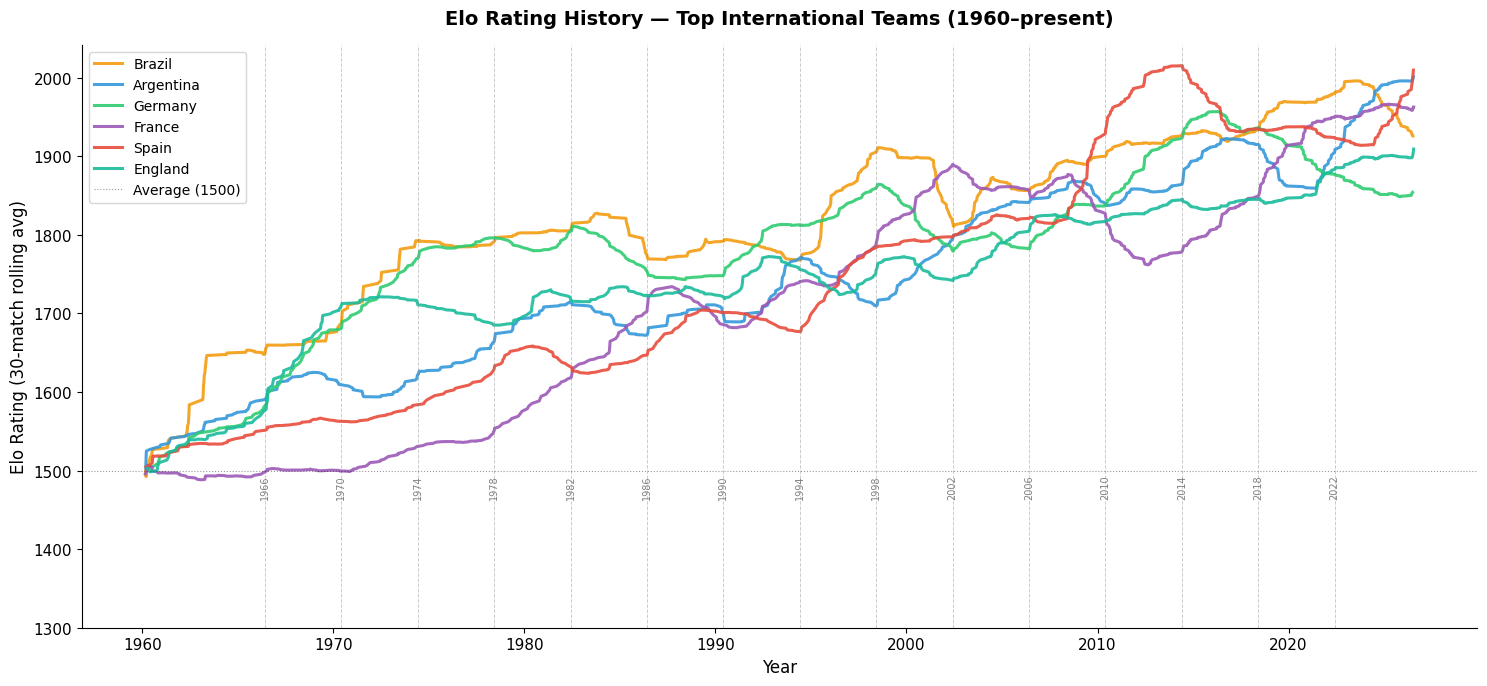

In [12]:
COLORS = {
    'Brazil':    '#f39c12',
    'Argentina': '#3498db',
    'Germany':   '#2ecc71',
    'France':    '#9b59b6',
    'Spain':     '#e74c3c',
    'England':   '#1abc9c',
}

# World Cup years to annotate
wc_years = [1966, 1970, 1974, 1978, 1982, 1986, 1990, 1994, 1998,
             2002, 2006, 2010, 2014, 2018, 2022]

fig, ax = plt.subplots(figsize=(15, 7))

for team in teams_to_track:
    tdf = history_df[history_df['team'] == team].copy()
    # Smooth with a 30-match rolling average so it's readable
    tdf = tdf.sort_values('date')
    tdf['smooth'] = tdf['elo_rating'].rolling(30, min_periods=1).mean()
    ax.plot(tdf['date'], tdf['smooth'],
            label=team, color=COLORS[team], linewidth=2.2, alpha=0.9)

# Add World Cup vertical lines
for yr in wc_years:
    ax.axvline(pd.Timestamp(f'{yr}-06-01'), color='gray',
               linewidth=0.7, linestyle='--', alpha=0.4)
    ax.text(pd.Timestamp(f'{yr}-06-01'), ax.get_ylim()[0] + 5,
            str(yr), fontsize=7, ha='center', color='gray', rotation=90)

ax.axhline(DEFAULT_RATING, color='black', linewidth=0.8,
           linestyle=':', alpha=0.4, label='Average (1500)')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Elo Rating (30-match rolling avg)', fontsize=12)
ax.set_title('Elo Rating History — Top International Teams (1960–present)',
             fontsize=14, pad=15, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.set_ylim(1300, None)

plt.tight_layout()
plt.savefig('../outputs/02_rating_history.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 6 — Validate: Match Prediction with Elo

In [13]:
def predict_match_elo(team_a, team_b, neutral=False):
    """
    Use the Elo ratings to predict win probabilities for a matchup.
    Note: Elo only gives 1 number (expected score), not win/draw/loss.
    We map it approximately here — Poisson model (Notebook 3) does this properly.
    """
    if team_a not in ratings_dict or team_b not in ratings_dict:
        print(f'Team not found in ratings.')
        return

    ra = ratings_dict[team_a]
    rb = ratings_dict[team_b]
    ha = 0 if neutral else HOME_ADVANTAGE

    # Elo expected result (0–1 scale, not a probability of win)
    e_a = expected_result(ra, rb, ha)

    rank_a = ratings_df[ratings_df['team'] == team_a]['rank'].values[0]
    rank_b = ratings_df[ratings_df['team'] == team_b]['rank'].values[0]

    print(f'\n{"═"*52}')
    label = '(Neutral)' if neutral else '(Home/Away)'
    print(f'  {team_a} vs {team_b}  {label}')
    print(f'  Elo #{rank_a} ({ra:.0f})  vs  Elo #{rank_b} ({rb:.0f})')
    print(f'{"─"*52}')
    print(f'  Elo expected score for {team_a}: {e_a:.3f}')
    print(f'  → {team_a} is {"favoured" if e_a > 0.5 else "the underdog"}')
    print(f'{"═"*52}')

# Test some matchups
predict_match_elo('Brazil', 'Argentina', neutral=True)
predict_match_elo('France', 'England', neutral=True)
predict_match_elo('Germany', 'Spain', neutral=True)
predict_match_elo('India', 'Brazil', neutral=True)


════════════════════════════════════════════════════
  Brazil vs Argentina  (Neutral)
  Elo #5 (1914)  vs  Elo #2 (2049)
────────────────────────────────────────────────────
  Elo expected score for Brazil: 0.314
  → Brazil is the underdog
════════════════════════════════════════════════════

════════════════════════════════════════════════════
  France vs England  (Neutral)
  Elo #3 (1972)  vs  Elo #4 (1969)
────────────────────────────────────────────────────
  Elo expected score for France: 0.505
  → France is favoured
════════════════════════════════════════════════════

════════════════════════════════════════════════════
  Germany vs Spain  (Neutral)
  Elo #11 (1852)  vs  Elo #1 (2059)
────────────────────────────────────────────────────
  Elo expected score for Germany: 0.233
  → Germany is the underdog
════════════════════════════════════════════════════

════════════════════════════════════════════════════
  India vs Brazil  (Neutral)
  Elo #287 (1328)  vs  Elo #5 (1914)
────

## Part 7 — Compare with FIFA Rankings

Let's see how our Elo rankings compare to the official FIFA world rankings.

In [14]:
# Official FIFA ranking (approximate, as of mid-2026)
# Source: FIFA.com
fifa_rankings = {
    'Argentina': 1,  'France': 2,   'Spain': 3,
    'England':   4,  'Brazil': 5,   'Portugal': 6,
    'Belgium':   7,  'Netherlands': 8, 'Germany': 9,
    'Italy':     10, 'Croatia': 11, 'Morocco': 12,
    'Colombia':  13, 'United States': 14, 'Uruguay': 15,
    'Mexico':    16, 'Denmark': 17, 'Senegal': 18,
    'Austria':   19, 'Japan': 20
}

comparison = []
for team, fifa_rank in fifa_rankings.items():
    elo_row = ratings_df[ratings_df['team'] == team]
    if not elo_row.empty:
        elo_rank   = int(elo_row['rank'].values[0])
        elo_rating = float(elo_row['elo_rating'].values[0])
        diff       = elo_rank - fifa_rank
        comparison.append({
            'team':       team,
            'fifa_rank':  fifa_rank,
            'elo_rank':   elo_rank,
            'elo_rating': elo_rating,
            'difference': diff
        })

comp_df = pd.DataFrame(comparison)

print('FIFA vs Elo Rankings Comparison')
print(f'{"Team":<22} {"FIFA":<6} {"Elo":<6} {"Elo Rating":<12} {"Diff"}')
print('─' * 58)
for _, row in comp_df.iterrows():
    diff_str = f'{row["difference"]:+d}'
    arrow    = '↑' if row['difference'] < 0 else ('↓' if row['difference'] > 0 else '=')
    print(f"{row['team']:<22} {row['fifa_rank']:<6} {row['elo_rank']:<6} "
          f"{row['elo_rating']:<12.0f} {arrow} {diff_str}")

FIFA vs Elo Rankings Comparison
Team                   FIFA   Elo    Elo Rating   Diff
──────────────────────────────────────────────────────────
Argentina              1      2      2049         ↓ +1
France                 2      3      1972         ↓ +1
Spain                  3      1      2059         ↑ -2
England                4      4      1969         = +0
Brazil                 5      5      1914         = +0
Portugal               6      7      1896         ↓ +1
Belgium                7      9      1868         ↓ +2
Netherlands            8      8      1883         = +0
Germany                9      11     1852         ↓ +2
Italy                  10     15     1829         ↓ +5
Croatia                11     16     1823         ↓ +5
Morocco                12     10     1866         ↑ -2
Colombia               13     6      1899         ↑ -7
United States          14     36     1726         ↓ +22
Uruguay                15     19     1805         ↓ +4
Mexico                 16   

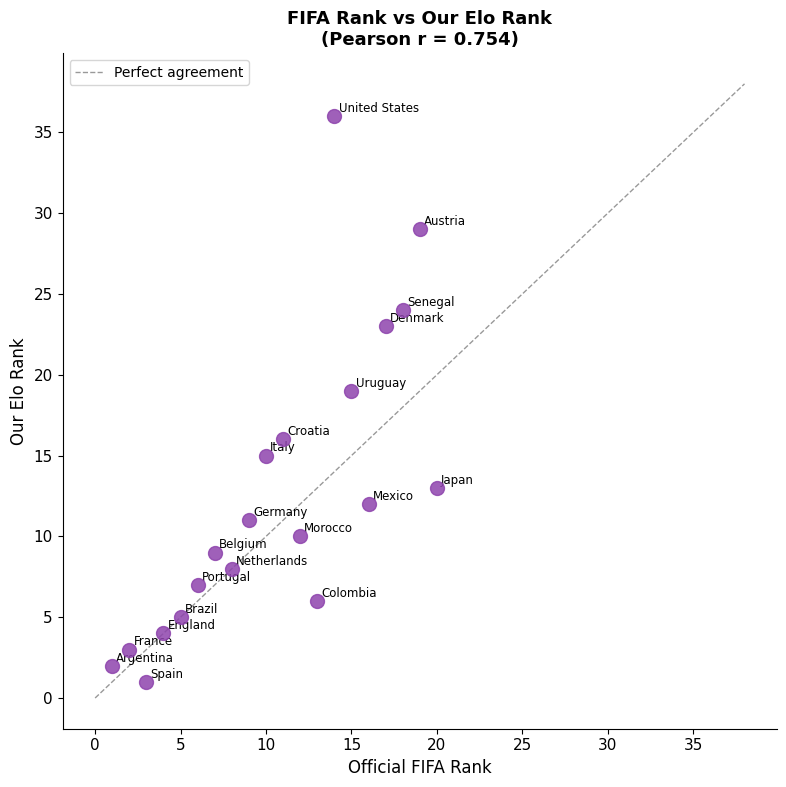

Pearson correlation: 0.754  (1.0 = perfect match)
Our Elo rankings correlate well with official FIFA rankings!


In [15]:
# Scatter plot: Elo rank vs FIFA rank
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(comp_df['fifa_rank'], comp_df['elo_rank'],
           s=100, color='#8e44ad', alpha=0.85, zorder=5)

# Perfect agreement line
max_rank = max(comp_df['fifa_rank'].max(), comp_df['elo_rank'].max()) + 2
ax.plot([0, max_rank], [0, max_rank], 'k--', linewidth=1,
        alpha=0.4, label='Perfect agreement')

# Annotate each team
for _, row in comp_df.iterrows():
    ax.annotate(row['team'],
                xy=(row['fifa_rank'], row['elo_rank']),
                xytext=(3, 3), textcoords='offset points', fontsize=8.5)

# Correlation
corr = comp_df['fifa_rank'].corr(comp_df['elo_rank'])
ax.set_title(f'FIFA Rank vs Our Elo Rank\n(Pearson r = {corr:.3f})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Official FIFA Rank', fontsize=12)
ax.set_ylabel('Our Elo Rank',       fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/02_elo_vs_fifa.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pearson correlation: {corr:.3f}  (1.0 = perfect match)')
print('Our Elo rankings correlate well with official FIFA rankings!')

## Part 8 — Save Ratings

In [16]:
os.makedirs('../outputs', exist_ok=True)

save_path = '../outputs/team_ratings.csv'
ratings_df.to_csv(save_path, index=False)

print(f'✓ Ratings saved to {save_path}')
print(f'  Shape: {ratings_df.shape}')
print()
print('Preview:')
ratings_df.head(10)

✓ Ratings saved to ../outputs/team_ratings.csv
  Shape: (333, 3)

Preview:


,team,elo_rating,rank
0,Spain,2058.797871,1
1,Argentina,2049.439391,2
2,France,1972.204220,3
3,England,1968.581348,4
4,Brazil,1913.521652,5
5,Colombia,1899.497696,6
6,Portugal,1895.829373,7
7,Netherlands,1883.480982,8
8,Belgium,1868.118502,9
9,Morocco,1866.435901,10


## ✅ Summary — What I Learned

| Concept | What it means |
|---|---|
| **Elo rating** | A number reflecting a team's current strength (1500 = average) |
| **Expected result** | The probability the home team "wins" based on rating gap |
| **K-factor** | Controls how fast ratings respond to results |
| **Tournament weight** | World Cup match matters more than a friendly |
| **Home advantage** | +100 Elo points added to the home team's effective rating |
| **Zero-sum** | Points gained by winner = points lost by loser |

---

### ⚠️ Elo's Limitation

Elo gives us one number — the **expected result** (0 to 1). It **cannot** directly give us:
- The probability of a **draw** specifically
- **Expected goals** (how many goals each team will score)
- A full **score probability distribution**

That's exactly what **Notebook 3 (Poisson model)** will solve. We'll use Elo ratings as the *input* to a Poisson regression that predicts actual scorelines. 🎯

In [17]:
# Quick summary printout
print('='*55)
print('ELO RATINGS — FINAL SUMMARY')
print('='*55)
print(f'Teams rated        : {len(ratings_df)}')
print(f'Matches processed  : {len(df):,}')
print(f'Top team           : {ratings_df.iloc[0]["team"]}  ({ratings_df.iloc[0]["elo_rating"]:.0f})')
print(f'Ratings saved to   : outputs/team_ratings.csv')
print()
print('Outputs generated:')
print('  outputs/02_elo_formula.png')
print('  outputs/02_top25_rankings.png')
print('  outputs/02_rating_distribution.png')
print('  outputs/02_rating_history.png')
print('  outputs/02_elo_vs_fifa.png')
print('  outputs/team_ratings.csv')
print()
print('NEXT → Notebook 03: Poisson Regression for Goal Prediction')

ELO RATINGS — FINAL SUMMARY
Teams rated        : 333
Matches processed  : 44,530
Top team           : Spain  (2059)
Ratings saved to   : outputs/team_ratings.csv

Outputs generated:
  outputs/02_elo_formula.png
  outputs/02_top25_rankings.png
  outputs/02_rating_distribution.png
  outputs/02_rating_history.png
  outputs/02_elo_vs_fifa.png
  outputs/team_ratings.csv

NEXT → Notebook 03: Poisson Regression for Goal Prediction
